<a href="https://colab.research.google.com/github/SivapriyaKG/colab-notebook/blob/main/AI_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  participant_id  age  gender          occupation         region  \
0        P300000   33    Male             Student  Latin America   
1        P300001   23  Female  Full-time employed        Oceania   
2        P300002   56  Female  Full-time employed         Africa   
3        P300003   13    Male             Student         Europe   
4        P300004   36  Female             Student           Asia   

  most_used_platform  platforms_used_count  daily_screen_hours  \
0             TikTok                     8                 3.2   
1          Instagram                     8                 4.5   
2          Instagram                     1                 5.3   
3            YouTube                     4                 3.4   
4           LinkedIn                     5                 5.8   

   daily_notifications night_time_use  ...  life_satisfaction_1to10  \
0                  172          Never  ...                        9   
1                   38          Often  ...          

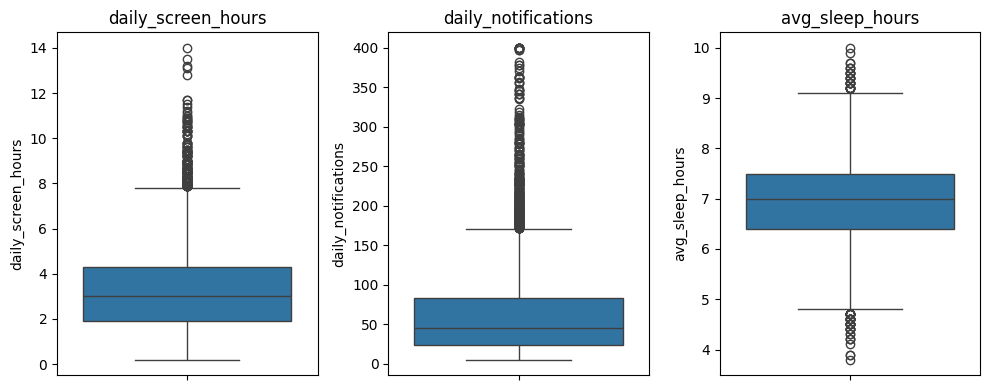

Missing values after cleaning:
participant_id                         0
age                                    0
gender                                 0
occupation                             0
region                                 0
most_used_platform                     0
platforms_used_count                   0
daily_screen_hours                     0
daily_notifications                    0
night_time_use                         0
minutes_to_first_check_after_waking    0
primary_purpose                        0
avg_sleep_hours                        0
anxiety_score_0to27                    0
low_mood_score_0to27                   0
life_satisfaction_1to10                0
loneliness_1to10                       0
self_esteem_1to10                      0
fomo_1to10                             0
social_comparison_1to10                0
physical_activity_days_per_week        0
uses_screen_time_limits                0
attempted_digital_detox                0
seeks_mental_health_suppor

,participant_id,age,gender,occupation,region,most_used_platform,platforms_used_count,daily_screen_hours,daily_notifications,night_time_use,...,life_satisfaction_1to10,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week,uses_screen_time_limits,attempted_digital_detox,seeks_mental_health_support,wellbeing_band
0,P300000,0.392271,Male,Student,Latin America,TikTok,2.554806,-0.041659,171.5,Never,...,9,6,4,6,8,4,No,No,No,At-risk
1,P300001,-0.652830,Female,Full-time employed,Oceania,Instagram,2.554806,0.687087,38.0,Often,...,7,5,8,5,8,4,No,"Yes, failed",Yes,At-risk
2,P300002,2.796005,Female,Full-time employed,Africa,Instagram,-1.414548,1.135546,74.0,Every night,...,8,7,3,2,3,5,No,No,No,Moderate
3,P300003,-1.697932,Male,Student,Europe,YouTube,0.286604,0.070456,49.0,Sometimes,...,10,6,6,1,5,4,No,"Yes, failed",Yes,Moderate
4,P300004,0.705802,Female,Student,Asia,LinkedIn,0.853654,1.415832,171.5,Never,...,4,6,8,7,9,3,Yes,"Yes, succeeded",No,Moderate


In [ ]:
#importing libraries
import pandas as pd
import numpy as np
#load the dataset
df = pd.read_csv("social_media_screentime_mental_health_2026.csv")
print(df.head())
#understand the dataset
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
#Check missing values
print("Missing values:")
print(df.isnull().sum())
#Handle the missing values
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['avg_sleep_hours'] = df['avg_sleep_hours'].fillna(
    df['avg_sleep_hours'].median()
)
print(df.isnull().sum())
#Check for duplicate values
print("Number of duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicate rows after removal:", df.duplicated().sum())
#Check important numerical values
print(df.describe())
#Detecting and Visualizing Outliers
import matplotlib.pyplot as plt
import seaborn as sns
outlier_cols = ['daily_screen_hours', 'daily_notifications', 'avg_sleep_hours']
plt.figure(figsize=(10, 4))
for i, col in enumerate(outlier_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

#Capping outliers using IQR
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = np.where(df[col] < (Q1 - 1.5 * IQR), Q1 - 1.5 * IQR, df[col])
    df[col] = np.where(df[col] > (Q3 + 1.5 * IQR), Q3 + 1.5 * IQR, df[col])

#Feature Scaling
from sklearn.preprocessing import StandardScaler
scale_cols = ['age', 'platforms_used_count', 'daily_screen_hours', 'avg_sleep_hours']
scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])
#Final verification
print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nDuplicate rows after cleaning:")
print(df.duplicated().sum())
print("\nCleaned dataset:")
display(df.head())